In [8]:
ge_freq = 8.02-0.00233#7.42
anharmonicity = -318e-3-0.00081

readout_freq = 10.297
qubit_lo_freq = 7.85
readout_lo_freq = 10.4 

2 * qubit_lo_freq - readout_lo_freq , 2 * ge_freq + anharmonicity - readout_freq

(5.299999999999999, 5.419529999999998)

In [9]:
readout_freq = 10.297
readout_lo_freq = 10.4 # 10.387
readout_if_freq = readout_lo_freq - readout_freq
JPA_if_freq = readout_freq * 2 - readout_lo_freq * 2

qubit_lo_freq = 7.85
ge_freq = 8.02-0.00233#7.42
anharmonicity = -318e-3-0.00081
ge_if_freq = ge_freq-qubit_lo_freq

fogi_lo_freq = 2 * qubit_lo_freq - readout_lo_freq 
fogi_lo_freq

5.299999999999999

## 11/8 ef calibration - DPR1-L-120-44

ef_freq =  (8.2779 -0.001898495-0.38408638 -0.0009)e9

ef_pi_amp = 0.976


T1 = 14.50e-06

T2 =

T2_star = 

In [1]:
from plottr.data.datadict_storage import datadict_from_hdf5
import numpy as np
import matplotlib.pyplot as plt
import lmfit

In [2]:
import sklearn
from sklearn.decomposition import PCA

In [3]:
def Rabi(delay, amp, phi0, detun, const):
    return - amp * np.cos(2*np.pi*detun*delay+phi0) + const

amp

In [29]:
header = "D:/K_sunada/result/CDY151/"
ef = "/2023-11-14/2023-11-14T113822_e12b5608-30_ef_pi_amp"
dd_ef = datadict_from_hdf5(header + ef +"/data")

In [30]:
def PCA_transform(Re_c, Im_c):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c]).T, np.array([Im_c]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    return c_PCA1, c_PCA2

In [31]:
Rabi_ef = dd_ef['s11']['values']
#imag_ge = Rabi_ge.imag
amp_ef = dd_ef['amplitude']['values']

I = (Rabi_ef.real)
Q = (Rabi_ef.imag)

PCAef = PCA_transform(I, Q)

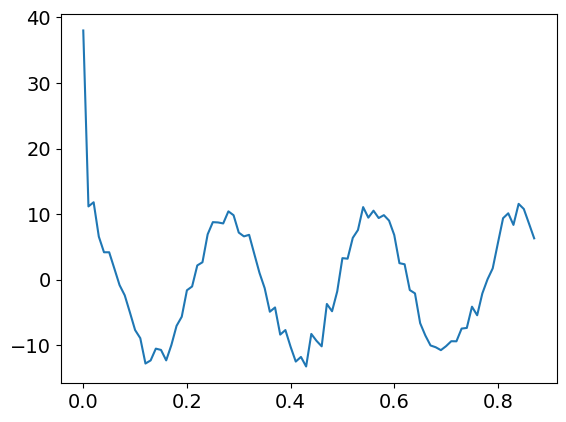

In [32]:
y = PCAef[0]
x = amp_ef

plt.plot(x, y)
plt.show()

In [37]:
par_ini = {
    'amp': 10,
    'phi0':np.pi,
    'detun':1/0.3,
    'const':0
}

par_min = {
    'amp': 0,
    'phi0':-2*np.pi,
    'detun':-np.inf,
    'const':0
}

par_max = {
    'amp': np.inf,
    'phi0':2*np.pi,
    'detun':np.inf,
    'const':np.inf,
}

par_vary = {
    'amp': True,
    'phi0':True,
    'detun':True,
    'const':True
}

In [38]:
model = lmfit.Model(Rabi)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

In [39]:
result_ef = model.fit(data = y, params = params, delay = x)
result_ef

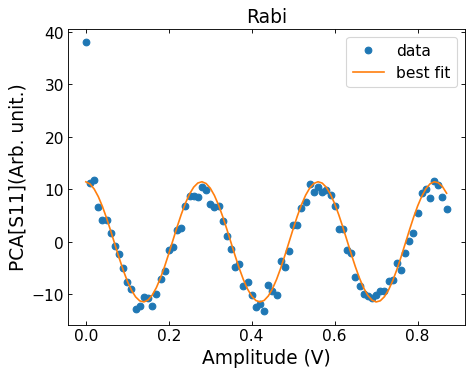

In [40]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi")


plt.rcParams["font.size"] = 14
plt.tick_params(
            top='on',
            bottom='on`',
            left='on',
            right='on',
            )
result_ef.plot_fit(ax = ax)
# plt.plot(amp_ef,result_ef.init_fit)

ax.tick_params(axis="x", direction="in")
ax.tick_params(axis="y", direction="in")
ax.set_xlabel("Amplitude (V)", size='large')
ax.set_ylabel("PCA[S11](Arb. unit.)", size='large')


plt.show()

In [41]:
np.pi/(	3.55412091*2*np.pi)*5

0.7034088212828977

ramsey

In [22]:
pl = "/2023-11-09/2023-11-09T100030_6126262c-32_ef_T2r1d"
mi = "/2023-11-09/2023-11-09T100235_ab4c6c1b-32_ef_T2r1d"
dd_pl = datadict_from_hdf5(header + pl +"/data")
dd_mi = datadict_from_hdf5(header + mi +"/data")

In [23]:
Rabi_pl = dd_pl['s11']['values']
imag_pl = Rabi_pl.imag
delay_pl = dd_pl['delay']['values']

Rabi_mi = dd_mi['s11']['values']
imag_mi = Rabi_mi.imag
delay_mi = dd_mi['delay']['values']

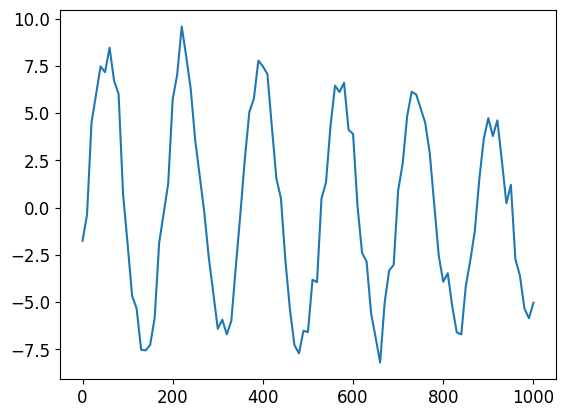

In [24]:
def PCA_transform(Re_c, Im_c):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c]).T, np.array([Im_c]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    return c_PCA1, c_PCA2


I_pl = (Rabi_pl.real)
Q_pl = (Rabi_pl.imag)
I_mi = (Rabi_mi.real)
Q_mi = (Rabi_mi.imag)


PCA_pl = PCA_transform(I_pl, Q_pl)
y_pl = PCA_pl[0]
x_pl = delay_pl

PCA_mi = PCA_transform(I_mi, Q_mi)
y_mi = PCA_mi[0]
x_mi = delay_mi



plt.plot(x_pl, y_pl)
plt.show()

In [25]:
par_ini_pl = {
    'amp': 7.5,
    'phi0':-np.pi,
    'detun':1/180,
    'const':0
}

par_min_pl = {
    'amp': 0,
    'phi0':-2*np.pi,
    'detun':-np.inf,
    'const':0
}

par_max_pl = {
    'amp': np.inf,
    'phi0':2*np.pi,
    'detun':np.inf,
    'const':np.inf,
}

par_vary_pl = {
    'amp': True,
    'phi0':True,
    'detun':True,
    'const':True
}

In [26]:
model = lmfit.Model(Rabi)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini_pl[name],
    min = par_min_pl[name],
    max = par_max_pl[name],
    vary = par_vary_pl[name]
    )
    
result_pl = model.fit(data = y_pl, params = params, delay = x_pl)
result_pl

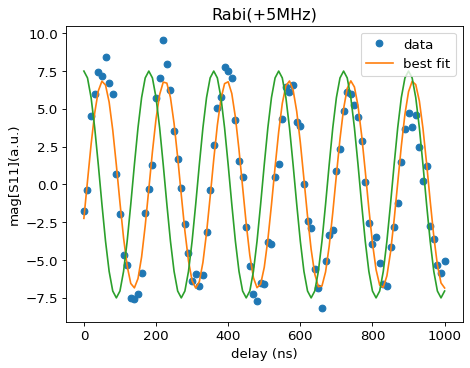

In [27]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi(+5MHz)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result_pl.plot_fit(ax = ax)
plt.plot(x_pl,result_pl.init_fit)

plt.xlabel("delay (ns)")
plt.ylabel("mag[S11](a.u.)")


plt.show()

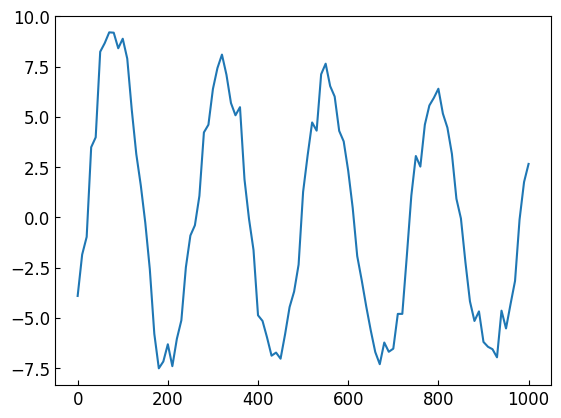

In [28]:
plt.plot(x_mi, y_mi)
plt.show()

In [29]:
par_ini_mi = {
    'amp': 7.5,
    'phi0':-np.pi/2,
    'detun':1/200,
    'const':0
}

par_min_mi = {
    'amp': 0,
    'phi0':-2*np.pi,
    'detun':-np.inf,
    'const':0
}

par_max_mi = {
    'amp': np.inf,
    'phi0':2*np.pi,
    'detun':np.inf,
    'const':np.inf,
}

par_vary_mi = {
    'amp': True,
    'phi0':True,
    'detun':True,
    'const':True
}

In [30]:
model = lmfit.Model(Rabi)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini_mi[name],
    min = par_min_mi[name],
    max = par_max_mi[name],
    vary = par_vary_mi[name]
    )
    
result_mi = model.fit(data = y_mi, params = params, delay = x_mi)
result_mi

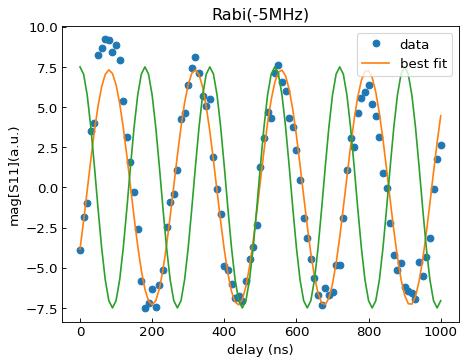

In [31]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi(-5MHz)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result_mi.plot_fit(ax = ax)
plt.plot(x_mi,result_pl.init_fit)

plt.xlabel("delay (ns)")
plt.ylabel("mag[S11](a.u.)")


plt.show()


In [32]:
detun = ((0.005-0.00581072)+ (	0.00419220-0.005))/2 #GHz
detun

-0.00080926

drag

In [33]:
drag = "/2023-11-09/2023-11-09T103854_be5b698c-31_ef_pi_drag"
dd_drag = datadict_from_hdf5(header + drag +"/data")

drag1 = "/2023-11-09/2023-11-09T103749_97830d1f-31_ef_pi_drag"
dd_drag1 = datadict_from_hdf5(header + drag1 +"/data")

drag2 = "/2023-11-09/2023-11-09T103553_52336533-31_ef_pi_drag"
dd_drag2 = datadict_from_hdf5(header + drag2 +"/data")

In [34]:
Rabi_drag = dd_drag['s11']['values']
imag_drag = Rabi_drag.imag
drag = dd_drag['beta']['values']
I_drag = (Rabi_drag.real)
Q_drag = (Rabi_drag.imag)

Rabi_drag1 = dd_drag1['s11']['values']
imag_drag1 = Rabi_drag1.imag
drag1 = dd_drag1['beta']['values']
I_drag1 = (Rabi_drag1.real)
Q_drag1 = (Rabi_drag1.imag)

Rabi_drag2 = dd_drag2['s11']['values']
imag_drag2 = Rabi_drag2.imag
drag2 = dd_drag2['beta']['values']
I_drag2 = (Rabi_drag2.real)
Q_drag2 = (Rabi_drag2.imag)

In [35]:
def PCA_transform1(Re_c_amp, Im_c_amp, Re_c_drag, Im_c_drag):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c_amp]).T, np.array([Im_c_amp]).T], axis = 1)
    c1_data = np.concatenate([np.array([Re_c_drag]).T, np.array([Im_c_drag]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    
    c1_pca = pca.transform(c1_data)
    c1_PCA1 = c1_pca.T[0]
    c1_PCA2 = c1_pca.T[1]
    return c_PCA1, c_PCA2, c1_PCA1, c1_PCA2,

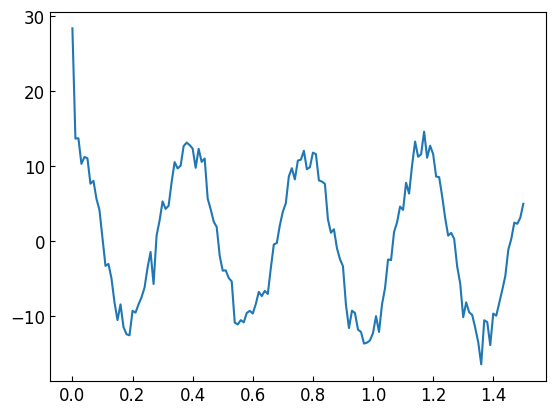

In [36]:
PCA_drag = PCA_transform1(I, Q, I_drag, Q_drag)
y = PCA_drag[0]
x = amp_ef
y0 = PCA_drag[2]
x0 = drag

PCA_drag1 = PCA_transform1(I, Q, I_drag1, Q_drag1)
y1 = PCA_drag1[2]
x1 = drag1

PCA_drag2 = PCA_transform1(I, Q, I_drag2, Q_drag2)
y2 = PCA_drag2[2]
x2 = drag2


plt.plot(x, y)
plt.show()

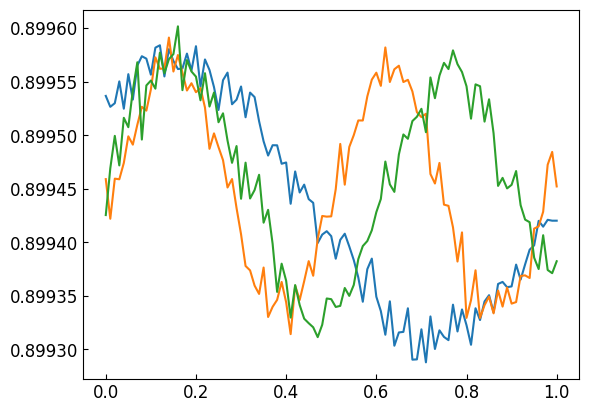

In [37]:
plt.plot(x0, y0)
plt.plot(x1, y1)
plt.plot(x2, y2)
plt.show()

In [38]:
par_ini= {
    'amp': 0.00015,
    'phi0':np.pi/2,
    'detun':1/0.5,
    'const':0.89945
}

par_min = {
    'amp': 0,
    'phi0':-2*np.pi,
    'detun':0,
    'const':-np.inf
}

par_max = {
    'amp': np.inf,
    'phi0':2*np.pi,
    'detun':np.inf,
    'const':np.inf,
}

par_vary = {
    'amp': True,
    'phi0':True,
    'detun':True,
    'const':True
}

In [39]:
model = lmfit.Model(Rabi)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )
    
result0 = model.fit(data = y0, params = params, delay = x0)
result1 = model.fit(data = y1, params = params, delay = x1)
result2 = model.fit(data = y2, params = params, delay = x2)

In [40]:
result0

In [41]:
res0 = (np.pi-2.29164748)/(2*np.pi*0.87150303)
res0

0.15521802113977118

In [42]:
result1

In [43]:
res1 = (np.pi-1.20688573)/(2*np.pi*2.08981927)
res1

0.14734200930371813

In [44]:
result2

In [45]:
res2 = (np.pi-1.48787363)/(2*np.pi*1.65008492)
res2

0.15950546174885247

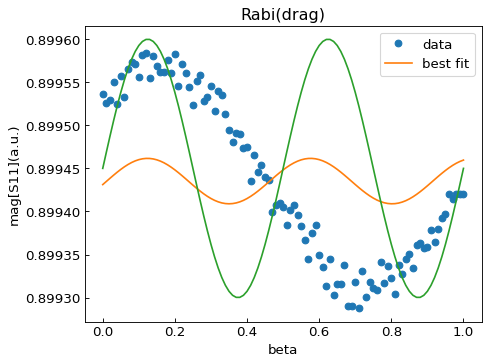

In [46]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi(drag)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result0.plot_fit(ax = ax)
plt.plot(x0,result0.init_fit)

plt.xlabel("beta")
plt.ylabel("mag[S11](a.u.)")

plt.show()

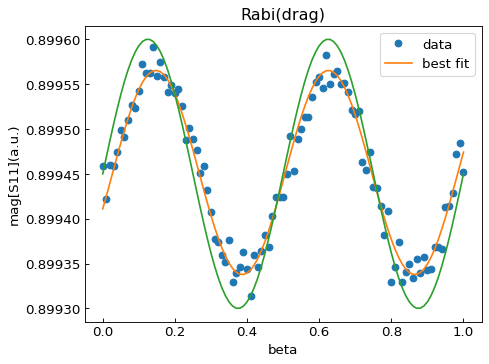

In [47]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi(drag)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result1.plot_fit(ax = ax)
plt.plot(x1,result1.init_fit)


plt.xlabel("beta")
plt.ylabel("mag[S11](a.u.)")

plt.show()

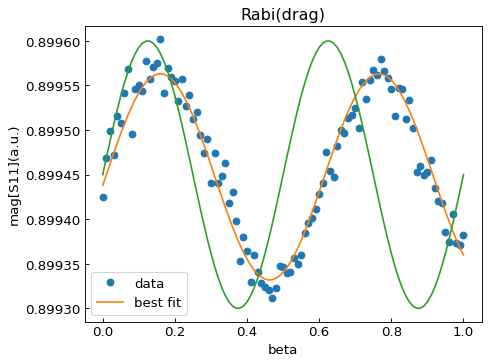

In [48]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi(drag)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result2.plot_fit(ax = ax)

plt.plot(x2,result2.init_fit)


plt.xlabel("beta")
plt.ylabel("mag[S11](a.u.)")

plt.show()


In [49]:
beta = (res0 + res1 + res2)/3
beta

0.1540218307307806

half drag

In [50]:
drag = "/2023-11-09/2023-11-09T105250_b028e29d-31_ef_pi_drag"
dd_drag = datadict_from_hdf5(header + drag +"/data")

drag1 = "/2023-11-09/2023-11-09T105400_d9e82cc5-31_ef_pi_drag"
dd_drag1 = datadict_from_hdf5(header + drag1 +"/data")

drag2 = "/2023-11-09/2023-11-09T105504_004c8509-31_ef_pi_drag"
dd_drag2 = datadict_from_hdf5(header + drag2 +"/data")

In [51]:
Rabi_drag = dd_drag['s11']['values']
imag_drag = Rabi_drag.imag
drag = dd_drag['beta']['values']
I_drag = (Rabi_drag.real)
Q_drag = (Rabi_drag.imag)

Rabi_drag1 = dd_drag1['s11']['values']
imag_drag1 = Rabi_drag1.imag
drag1 = dd_drag1['beta']['values']
I_drag1 = (Rabi_drag1.real)
Q_drag1 = (Rabi_drag1.imag)

Rabi_drag2 = dd_drag2['s11']['values']
imag_drag2 = Rabi_drag2.imag
drag2 = dd_drag2['beta']['values']
I_drag2 = (Rabi_drag2.real)
Q_drag2 = (Rabi_drag2.imag)

In [52]:
def PCA_transform1(Re_c_amp, Im_c_amp, Re_c_drag, Im_c_drag):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c_amp]).T, np.array([Im_c_amp]).T], axis = 1)
    c1_data = np.concatenate([np.array([Re_c_drag]).T, np.array([Im_c_drag]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    
    c1_pca = pca.transform(c1_data)
    c1_PCA1 = c1_pca.T[0]
    c1_PCA2 = c1_pca.T[1]
    return c_PCA1, c_PCA2, c1_PCA1, c1_PCA2,

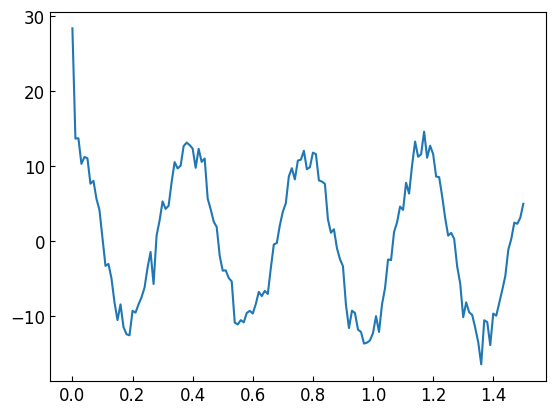

In [53]:
PCA_drag = PCA_transform1(I, Q, I_drag, Q_drag)
y = PCA_drag[0]
x = amp_ef
y0 = PCA_drag[2]
x0 = drag

PCA_drag1 = PCA_transform1(I, Q, I_drag1, Q_drag1)
y1 = PCA_drag1[2]
x1 = drag1

PCA_drag2 = PCA_transform1(I, Q, I_drag2, Q_drag2)
y2 = PCA_drag2[2]
x2 = drag2


plt.plot(x, y)
plt.show()

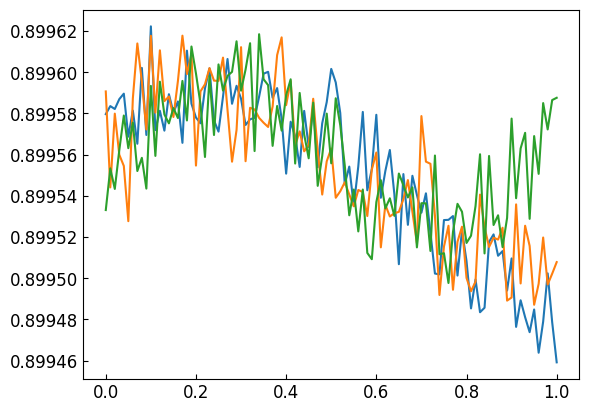

In [54]:
plt.plot(x0, y0)
plt.plot(x1, y1)
plt.plot(x2, y2)
plt.show()

In [55]:
par_ini= {
    'amp': 0.00006,
    'phi0':np.pi/2,
    'detun':1/1.1,
    'const':0.89954
}

par_min = {
    'amp': 0,
    'phi0':-2*np.pi,
    'detun':-np.inf,
    'const':0
}

par_max = {
    'amp': np.inf,
    'phi0':2*np.pi,
    'detun':np.inf,
    'const':np.inf,
}

par_vary = {
    'amp': True,
    'phi0':True,
    'detun':True,
    'const':True
}

In [56]:
model = lmfit.Model(Rabi)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )
    
result0 = model.fit(data = y0, params = params, delay = x0)
result1 = model.fit(data = y1, params = params, delay = x1)
result2 = model.fit(data = y2, params = params, delay = x2)

In [57]:
result0

In [58]:
res0 = (np.pi-2.56353244)/(2*np.pi*0.42779581)
res0

0.21505853551387613

In [59]:
result1

In [60]:
res1 = (2*np.pi-4.30230786)/(2*np.pi*1.63131373)
res1

0.1932592312441862

In [61]:
result2

In [62]:
res2 = (1*np.pi-1.20185553)/(2*np.pi*1.12022158)
res2

0.2755872204480923

In [63]:
(res0+res1+res2)/3

0.22796832906871822

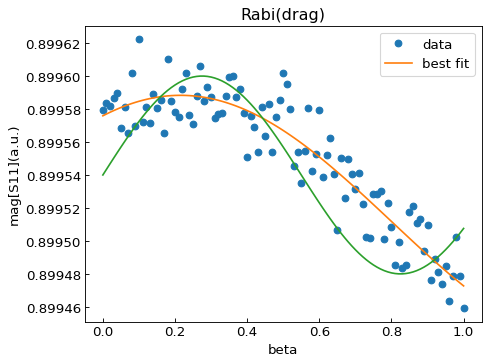

In [64]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi(drag)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result0.plot_fit(ax = ax)
plt.plot(x0,result0.init_fit)


plt.xlabel("beta")
plt.ylabel("mag[S11](a.u.)")

plt.show()

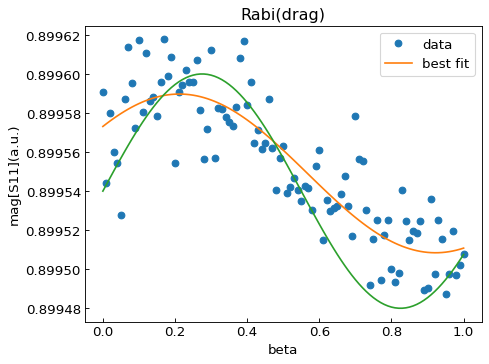

In [65]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi(drag)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result1.plot_fit(ax = ax)
plt.plot(x1,result1.init_fit)


plt.xlabel("beta")
plt.ylabel("mag[S11](a.u.)")

plt.show()

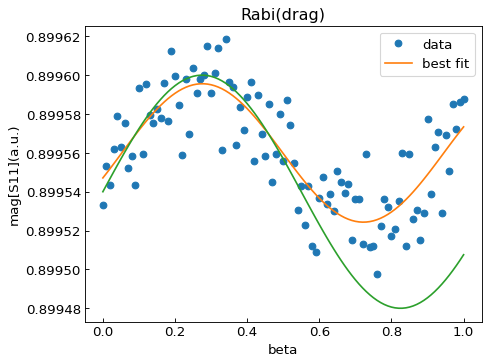

In [66]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi(drag)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result2.plot_fit(ax = ax)

plt.plot(x2,result2.init_fit)


plt.xlabel("beta")
plt.ylabel("mag[S11](a.u.)")

plt.show()


T1

In [67]:
def Dephase(delay, amp, gamma, const):
    return amp*np.exp(-gamma*delay) + const

t1 ="/2023-11-09/2023-11-09T101024_c306f41e-33_ef_T1"

dd_t1 = datadict_from_hdf5(header + t1 +"/data")

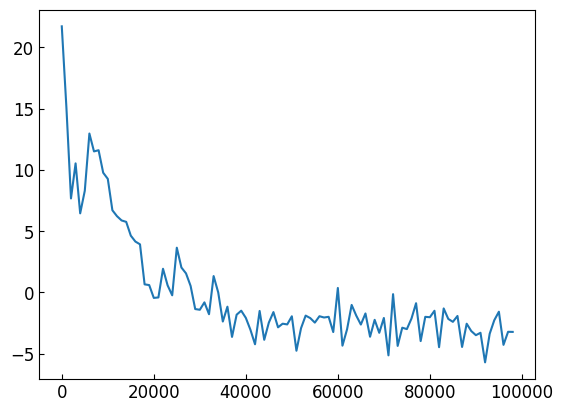

In [68]:
s11_t1 = dd_t1['s11']['values'][0:99]
imag_t1 = s11_t1.imag
delay_t1 = dd_t1['delay']['values'][0:99]

I_t1 = (s11_t1.real)
Q_t1 = (s11_t1.imag)

PCA_t1 = PCA_transform(I_t1, Q_t1)

y_t1 = PCA_t1[0]
x_t1 = delay_t1

plt.plot(x_t1, y_t1)
plt.show()

In [69]:
par_ini_t1 = {
    'gamma': 1/20000,
    'amp':20,
    'const':-5
}

par_min_t1 = {
    'gamma': 0,
    'amp':0,
    'const':-np.inf
}

par_max_t1 = {
    'gamma': np.inf,
    'amp':np.inf,
    'const':np.inf,
}

par_vary_t1 = {
    'gamma': True,
    'amp':True,
    'const':True
}

In [70]:
model = lmfit.Model(Dephase)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini_t1[name],
    min = par_min_t1[name],
    max = par_max_t1[name],
    vary = par_vary_t1[name]
    )
result_t1 = model.fit(data = y_t1, params = params, delay = x_t1)
result_t1

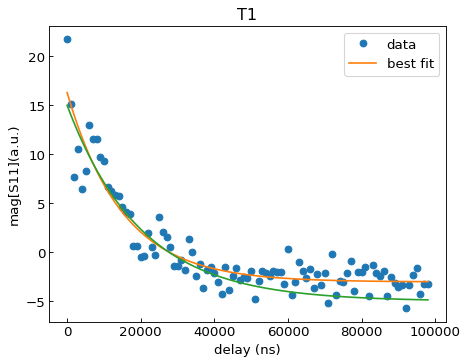

In [71]:
fig, ax = plt.subplots(dpi=80)

plt.title("T1")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result_t1.plot_fit(ax = ax)
plt.plot(delay_t1,result_t1.init_fit)

plt.xlabel("delay (ns)")
plt.ylabel("mag[S11](a.u.)")

plt.show()

In [72]:
T1 = (1/6.6683e-05)*1e-9	
T1

1.4996325900154463e-05

## no data

T2_star

In [73]:
t2e = "/2023-07-01/2023-07-01T181335_8e8e04ba-td_ge_T2e"
dd_t2e = datadict_from_hdf5(header + t2e +"/data")

ValueError: Specified file does not exist.

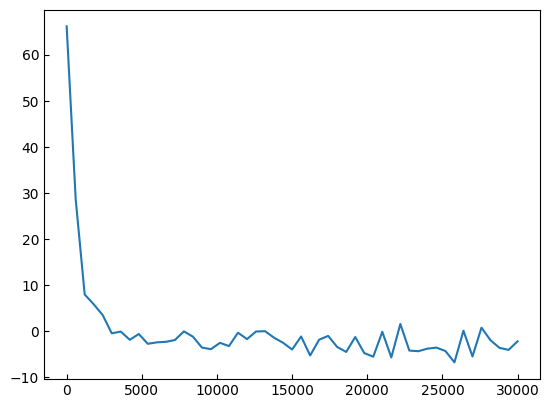

In [ ]:
s11_t2e = dd_t2e['s11']['values']
imag_t2e = s11_t2e.imag
delay_t2e = dd_t2e['delay']['values']

I_t2e = (s11_t2e.real)
Q_t2e = (s11_t2e.imag)

PCA_t2e = PCA_transform(I_t2e, Q_t2e)

y_t2e = PCA_t2e[0]
x_t2e = delay_t2e

plt.plot(x_t2e, y_t2e)
plt.show()

In [ ]:
par_ini_t2e = {
    'gamma': 1/2000,
    'amp':70,
    'const':0
}

par_min_t2e = {
    'gamma': 0,
    'amp':0,
    'const':-np.inf
}

par_max_t2e = {
    'gamma': np.inf,
    'amp':np.inf,
    'const':np.inf,
}

par_vary_t2e = {
    'gamma': True,
    'amp':True,
    'const':True
}

In [ ]:
model = lmfit.Model(Dephase)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini_t2e[name],
    min = par_min_t2e[name],
    max = par_max_t2e[name],
    vary = par_vary_t2e[name]
    )
result_t2e = model.fit(data = y_t2e, params = params, delay = x_t2e)
result_t2e

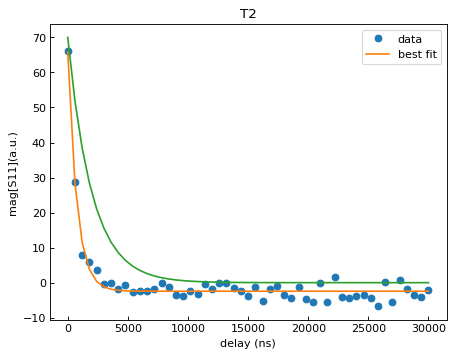

In [ ]:
fig, ax = plt.subplots(dpi=80)

plt.title("T2")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result_t2e.plot_fit(ax = ax)
plt.plot(delay_t2e,result_t2e.init_fit)

plt.xlabel("delay (ns)")
plt.ylabel("mag[S11](a.u.)")

plt.show()

In [ ]:
T2 = (1/0.00132869)*1e-9	
T2

7.526210026416998e-07

T2 star

In [ ]:
def Damping(delay, amp, gamma, omega, phi0, const):
    return const + amp * np.exp(- gamma*delay)*np.cos(omega*delay + phi0)

In [ ]:
t2 = "/2023-07-01/2023-07-01T182745_892e135d-td_ge_T2r1d"
dd_t2 = datadict_from_hdf5(header + t2 +"/data")

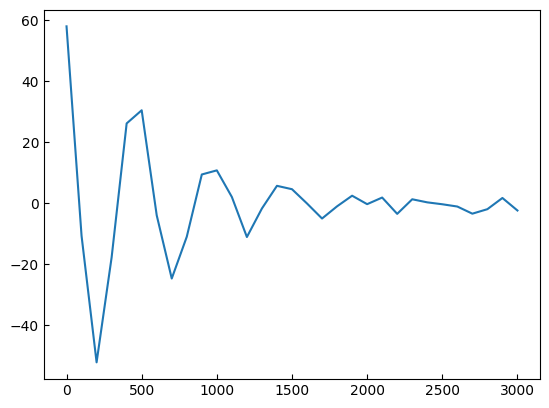

In [ ]:
s11_t2 = dd_t2['s11']['values']
imag_t2 = s11_t2.imag
delay_t2 = dd_t2['delay']['values']

I_t2 = (s11_t2.real)
Q_t2 = (s11_t2.imag)

PCA_t2 = PCA_transform(I_t2, Q_t2)

y_t2 = PCA_t2[0]
x_t2 = delay_t2

plt.plot(x_t2, y_t2)
plt.show()

In [ ]:
par_ini_t2 = {
    'amp':60,
    'gamma': 1/1500,
    'omega':2*np.pi/500,
    'phi0':0,
    'const':0
}

par_min_t2 = {
    'amp':-np.inf,
    'gamma': 0,
    'omega':-2*np.pi,
    'phi0':-2*np.pi,
    'const':-np.inf
}

par_max_t2 = {
    'amp':np.inf,
    'gamma': np.inf,
    'omega':2*np.pi,
    'phi0':2*np.pi,
    'const':np.inf
}

par_vary_t2 = {
    'amp':True,
    'gamma': True,
    'omega':True,
    'phi0':True,
    'const':True
}

In [ ]:
model = lmfit.Model(Damping)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini_t2[name],
    min = par_min_t2[name],
    max = par_max_t2[name],
    vary = par_vary_t2[name]
    )
result_t2 = model.fit(data = y_t2, params = params, delay = x_t2)
result_t2

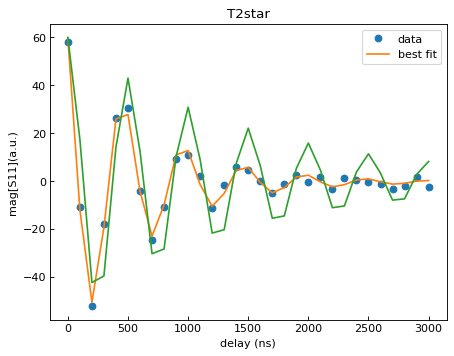

In [ ]:
fig, ax = plt.subplots(dpi=80)

plt.title("T2star")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result_t2.plot_fit(ax = ax)
plt.plot(delay_t2,result_t2.init_fit)

plt.xlabel("delay (ns)")
plt.ylabel("mag[S11](a.u.)")

plt.show()

In [ ]:
T2_star = (1/0.00157781	)*1e-9	
T2_star

6.337898733054044e-07